# **Assignment: Heart Disease Prediction Using KNN**
## **Objective**
Build and evaluate a **K-Nearest Neighbors (KNN)** classifier to predict heart disease using clinical features.

---

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix

## **Dataset**
Use the **Heart Failure Prediction Dataset** from Kaggle  
(Target column: `HeartDisease`, 918 rows).

In [ ]:
df = pd.read_csv('heart.csv')
df.head(3)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0


In [ ]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
None


## **Tasks**

### **1. Data Preparation**
- Load dataset using Pandas.  
- Encode categorical columns:  
  `Sex`, `ChestPainType`, `RestingECG`, `ExerciseAngina`, `ST_Slope`.  
- Split data into **80% training** and **20% testing**.  
- Apply **StandardScaler** on numerical features.

---

In [ ]:
print(df.isnull().sum())

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [ ]:
df_copy = df.copy()

In [ ]:
categorical_cols = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

label_encoder = LabelEncoder()

for col in categorical_cols:
    if col in df.columns:
        df[col] = label_encoder.fit_transform(df[col])
        print(f"Encoded column: {col}")
    else:
        print(f"Column '{col}' not found in DataFrame.")

print("\nDataFrame after encoding categorical columns:")
display(df.head())

Encoded column: Sex
Encoded column: ChestPainType
Encoded column: RestingECG
Encoded column: ExerciseAngina
Encoded column: ST_Slope

DataFrame after encoding categorical columns:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,1,1,140,289,0,1,172,0,0.0,2,0
1,49,0,2,160,180,0,1,156,0,1.0,1,1
2,37,1,1,130,283,0,2,98,0,0.0,2,0
3,48,0,0,138,214,0,1,108,1,1.5,1,1
4,54,1,2,150,195,0,1,122,0,0.0,2,0


In [ ]:
# Features (X) and target (y)
X = df.drop('HeartDisease', axis=1)
y = df['HeartDisease']

# 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 734
Testing samples: 184


In [ ]:
# Standardize features
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler on test data
X_test_scaled = scaler.transform(X_test)

print("Training set shape:", X_train_scaled.shape)
print("Testing set shape:", X_test_scaled.shape)

Training set shape: (734, 11)
Testing set shape: (184, 11)


### **2. Train KNN Model**
- Train a **KNN classifier** using `KNeighborsClassifier`.

In [ ]:
# KNN with default parameters
knn_default = KNeighborsClassifier()

knn_default.fit(X_train_scaled, y_train)

y_pred = knn_default.predict(X_test_scaled)


### **3. Hyperparameter Tuning**
Use Hyperparameters to tune:
- `n_neighbors` (e.g., 1–20)

Select the best-performing model.

In [ ]:
from sklearn.model_selection import GridSearchCV
# Create KNN model
knn = KNeighborsClassifier()

# Define hyperparameter grid
param_grid = {'n_neighbors': range(1, 21)}

# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(estimator=knn,param_grid= param_grid,cv=5, scoring='accuracy',
    n_jobs=-1)

# Fit on training data
grid_search.fit(X_train_scaled, y_train)

# Best hyperparameter
print("Best n_neighbors:", grid_search.best_params_['n_neighbors'])

# Best cross-validation score
print("Best CV Accuracy:", grid_search.best_score_)

# Best model
best_knn = grid_search.best_estimator_

Best n_neighbors: 13
Best CV Accuracy: 0.8596589320659771


In [ ]:
y_pred = best_knn.predict(X_test_scaled)

### **4. Model Evaluation**
Evaluate the KNN model using:
- Accuracy  
- Confusion Matrix

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 0.8315217391304348
Accuracy: 83.15%


In [ ]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[67 10]
 [21 86]]


### **5. Visualization**
- Plot the **Confusion Matrix**.

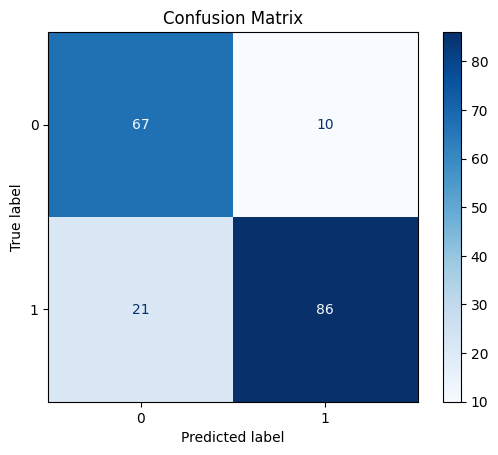

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_knn,
    X_test_scaled,
    y_test,
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.show()

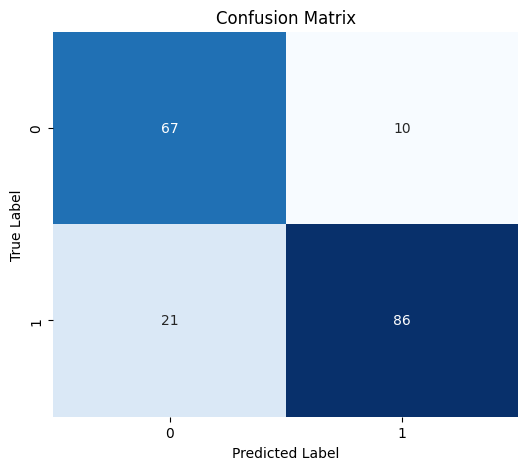

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Predict on test set
y_pred = best_knn.predict(X_test_scaled)

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

## **Bonus (Optional)**
Discuss whether KNN is suitable for real-world medical diagnosis and why.